In [23]:
data_path = "/kaggle/input/blood-cells-wout-shrek/"
master_path = "/kaggle/working/"

In [24]:
import os
import gc
# from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl
from tensorflow.keras import models, callbacks
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import plotly.graph_objects as go
from imblearn.over_sampling import SMOTE
import keras_cv
from tensorflow.data import Dataset
from imblearn.under_sampling import RandomUnderSampler
from tensorflow.keras.utils import plot_model
# import visualkeras
from PIL import ImageFont
from sklearn.utils import class_weight

import random

seed = 42

random.seed(seed)

In [25]:
data = np.load(os.path.join(data_path, 'preprocessed_training_set.npz'), allow_pickle=True)
# Print the keys in the .npz file
print("Keys in the .npz file:", list(data.keys()))

X = data['images']
y = data['labels']

Keys in the .npz file: ['images', 'labels']


# Show original Images

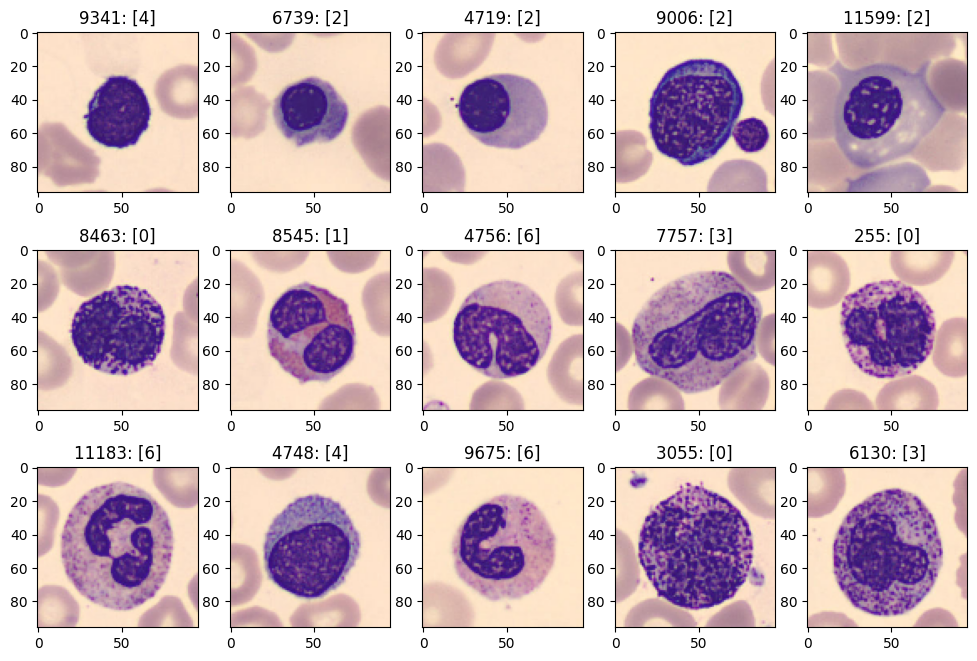

In [26]:
plt.figure(figsize=(12, 8))
for i in range(15):
  rand= np.random.choice(range(len(X)))

  plt.subplot(3, 5, i + 1)
  plt.imshow(X[rand], cmap='gray')
  plt.title(str(rand) + ": " + str(y[rand]))

# Display the images
plt.show()

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42, test_size=.20)

# Removing background

Processing images: 100%|██████████| 9567/9567 [08:08<00:00, 19.59it/s]


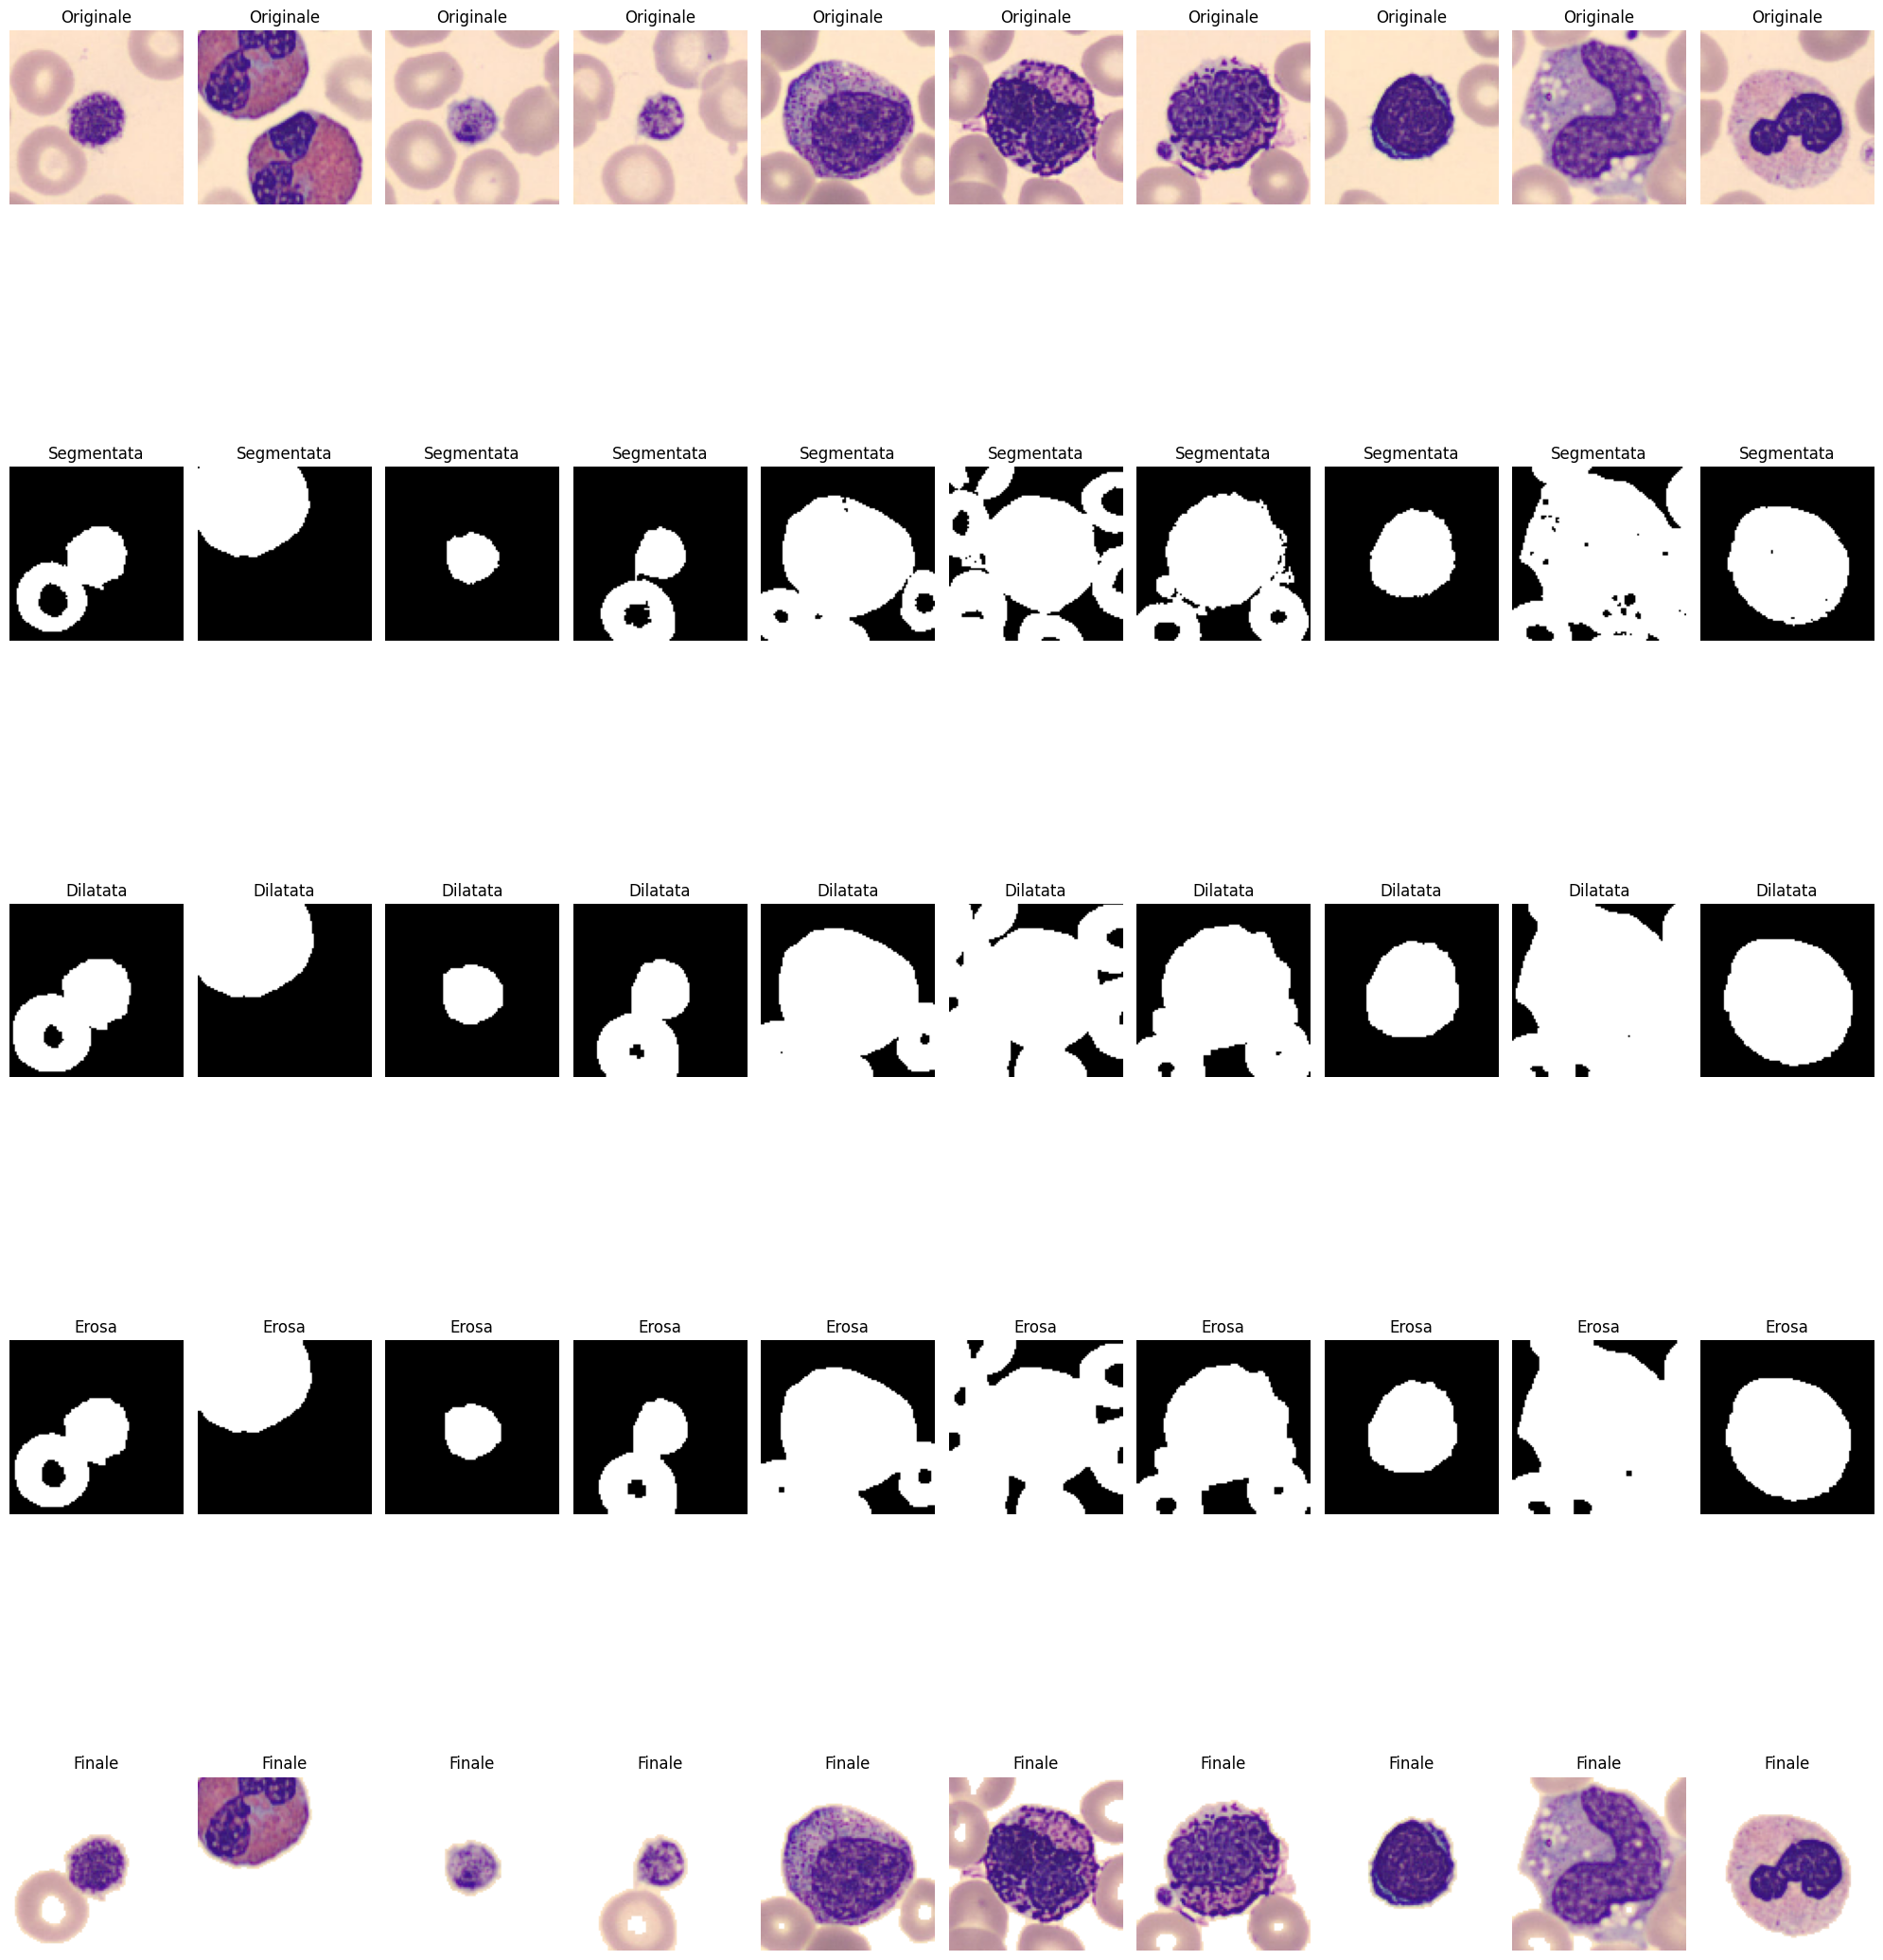

In [28]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

def region_growing(image, seed, threshold):
    """
    Algoritmo a goccia per identificare regioni di interesse basate su un seed iniziale.

    Args:
        image (numpy array): Immagine di input in scala di grigi.
        seed (tuple): Coordinate del pixel seed (x, y).
        threshold (int): Soglia di somiglianza per includere pixel nella regione.

    Returns:
        numpy array: Maschera binaria della regione segmentata.
    """
    h, w = image.shape
    segmented = np.zeros((h, w), dtype=np.uint8)
    to_process = [tuple(seed)]  # Assicurati che il seed sia una tupla
    seed_val = image[seed]

    while to_process:
        x, y = to_process.pop(0)
        if segmented[x, y] == 0:  # Non ancora visitato
            diff = abs(int(image[x, y]) - int(seed_val))
            if diff <= threshold:
                segmented[x, y] = 255  # Marca come parte della regione
                # Controlla i vicini
                for nx, ny in [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]:
                    if 0 <= nx < h and 0 <= ny < w and segmented[nx, ny] == 0:
                        to_process.append((nx, ny))
    return segmented

def isolate_cells_with_region_growing(image, seeds, threshold):
    """
    Applica l'algoritmo a goccia per identificare le cellule in un'immagine RGB.

    Args:
        image (numpy array): Immagine di input (RGB).
        seeds (list of tuples): Lista di coordinate dei punti seed.
        threshold (int): Soglia di somiglianza per l'algoritmo.

    Returns:
        numpy array: Immagine binaria con le regioni segmentate.
    """
    # Converti l'immagine in scala di grigi
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Inizializza una maschera vuota
    mask = np.zeros_like(gray_image, dtype=np.uint8)

    # Applica l'algoritmo di region growing per ciascun seed
    for seed in seeds:
        region = region_growing(gray_image, seed, threshold)
        mask = cv2.bitwise_or(mask, region)

    return mask

def process_dataset_with_region_growing(dataset, threshold):
    """
    Applica l'algoritmo a goccia a un intero dataset di immagini per segmentare le cellule.

    Args:
        dataset (list or numpy array): Lista o array di immagini (RGB).
        threshold (int): Soglia di somiglianza per l'algoritmo.

    Returns:
        tuple: Dataset elaborato con le cellule segmentate e con maschere dilatate ed erose.
    """
    processed_images = []
    dilated_images = []
    eroded_images = []
    final_images = []

    for image in tqdm(dataset, desc="Processing images"):
        # Trova il pixel più scuro come seed
        gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        seed = np.unravel_index(np.argmin(gray_image), gray_image.shape)

        # Step 1: Region Growing
        segmented = isolate_cells_with_region_growing(image, [seed], threshold)
        processed_images.append(segmented)

        # Step 2: Dilation
        kernel = np.ones((3, 3), np.uint8)  # Kernel per la dilatazione
        dilated = cv2.dilate(segmented, kernel, iterations=2)
        dilated_images.append(dilated)

        # Step 3: Erosion
        eroded = cv2.morphologyEx(dilated, cv2.MORPH_ERODE, kernel)
        eroded_images.append(eroded)

        # Step 4: Crea immagine finale
        foreground_mask = eroded
        masked_image = image.copy()
        masked_image[foreground_mask == 0] = [255, 255, 255]  # Imposta il background a bianco
        final_images.append(masked_image)

    return (np.array(processed_images), 
            np.array(dilated_images), 
            np.array(eroded_images), 
            np.array(final_images))

# Esempio di utilizzo (dati X_train e X_train_2):
num_img = 10
random_indices = random.sample(range(9567), num_img)

# Pre-elabora il dataset usando il pixel più scuro come seed
segmented_images, dilated_images, eroded_images, final_images = process_dataset_with_region_growing(X_train, threshold=165)

# Salva il dataset preprocessato
X_train_preprocessed = final_images

if True: 
    # Imposta il layout con cinque righe (originale, segmentata, dilatata, erosa, immagine finale)
    fig, axes = plt.subplots(5, num_img, figsize=(20, 25))
    
    # Itera attraverso gli indici selezionati casualmente
    for i, idx in enumerate(random_indices):
        # Immagini originali
        ax_orig = axes[0, i]
        ax_orig.imshow(np.squeeze(X_train[idx]), vmin=0., vmax=1.)
        ax_orig.set_title("Originale")
        ax_orig.axis('off')
    
        # Immagini con cellule segmentate
        ax_seg = axes[1, i]
        ax_seg.imshow(np.squeeze(segmented_images[idx]), cmap='gray', vmin=0, vmax=255)
        ax_seg.set_title("Segmentata")
        ax_seg.axis('off')
    
        # Immagini dilatate
        ax_dil = axes[2, i]
        ax_dil.imshow(np.squeeze(dilated_images[idx]), cmap='gray', vmin=0, vmax=255)
        ax_dil.set_title("Dilatata")
        ax_dil.axis('off')
    
        # Immagini erose
        ax_ero = axes[3, i]
        ax_ero.imshow(np.squeeze(eroded_images[idx]), cmap='gray', vmin=0, vmax=255)
        ax_ero.set_title("Erosa")
        ax_ero.axis('off')
    
        # Immagini finali (originale mascherata dalla erosa)
        ax_final = axes[4, i]
        ax_final.imshow(final_images[idx])
        ax_final.set_title("Finale")
        ax_final.axis('off')

    # Regola il layout e mostra le immagini
    plt.tight_layout()
    plt.show()


# Saving the new Dataset

In [29]:
np.savez('train_preprocessed_background_removed.npz', images=X_train_preprocessed, labels=y_train)
np.savez('validation_vanilla.npz', images=X_val, labels=y_val)

In [30]:
data = np.load('/kaggle/working/train_preprocessed_background_removed.npz', allow_pickle=True)
# Print the keys in the .npz file
print("Keys in the .npz file:", list(data.keys()))

X = data['images']
y = data['labels']



Keys in the .npz file: ['images', 'labels']


# Showing the differences 

Keys in the preprocessed .npz file: ['images', 'labels']
9567
9567
Tutte le etichette corrispondono tra il dataset originale e preprocessato.


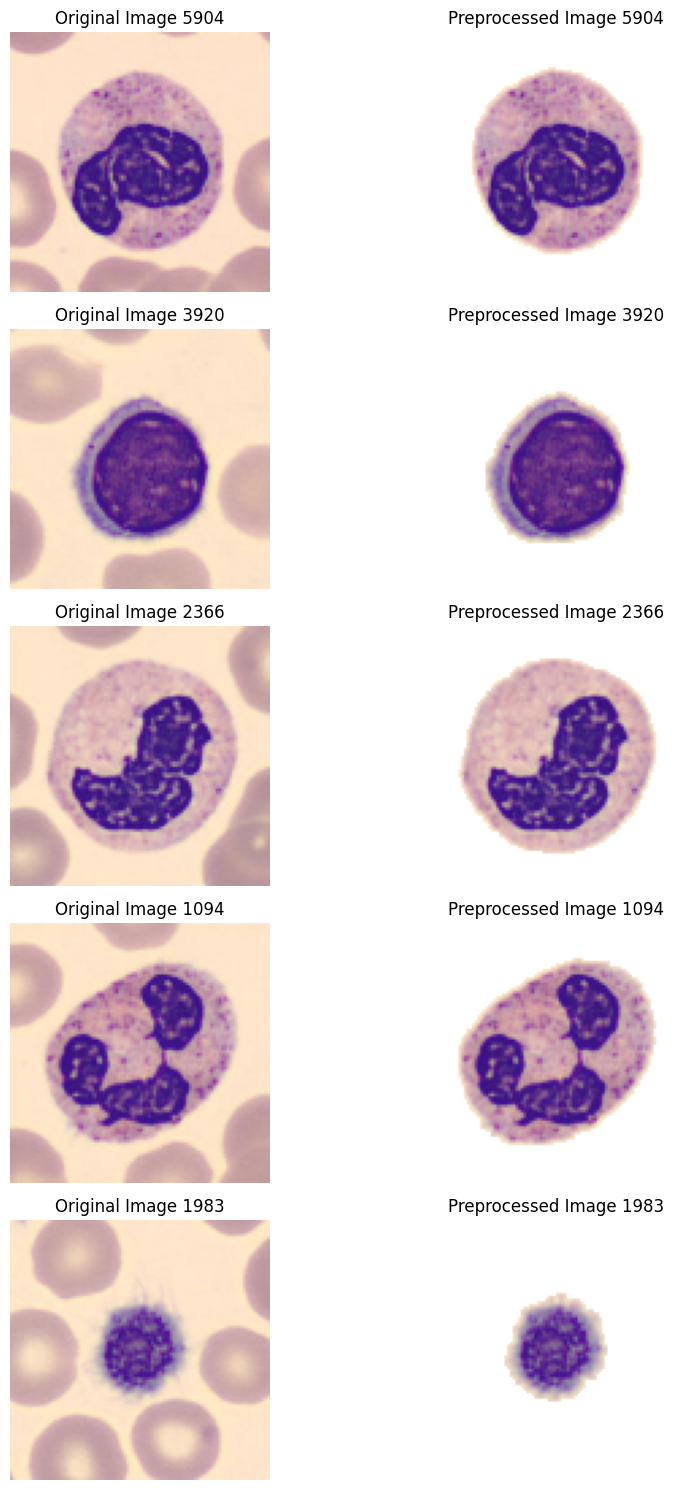

In [31]:
import time
# Carica il dataset preprocessato
preprocessed_data = np.load('/kaggle/working/train_preprocessed_background_removed.npz', allow_pickle=True)

# Stampa le chiavi del dataset preprocessato
print("Keys in the preprocessed .npz file:", list(preprocessed_data.keys()))

X_train_preprocessed = preprocessed_data['images']
y_train_preprocessed = preprocessed_data['labels']

print(len(X_train))
print(len(X_train_preprocessed))

# Verifica che le etichette corrispondano
assert len(X_train) == len(X_train_preprocessed), "Le dimensioni delle immagini non corrispondono!"
assert np.array_equal(y_train, y_train_preprocessed), "Le etichette non corrispondono!"

print("Tutte le etichette corrispondono tra il dataset originale e preprocessato.")

# Visualizza alcune immagini per confronto
num_samples = 5  # Numero di immagini da confrontare
indices = np.random.choice(len(X_train), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 2, figsize=(10, 15))

for i, idx in enumerate(indices):
    # Immagine originale
    axes[i, 0].imshow(X_train[idx])
    axes[i, 0].set_title(f"Original Image {idx}")
    axes[i, 0].axis('off')

    # print(y_train[idx])
    
    # Immagine preprocessata
    axes[i, 1].imshow(X_train_preprocessed[idx])
    axes[i, 1].set_title(f"Preprocessed Image {idx}")
    axes[i, 1].axis('off')

    # print(y_train_preprocessed[idx])

plt.tight_layout()
plt.show()